# 02 — Preprocessing

## Step 1: Understand the dataset before changing it

The original Daphnet recordings are whitespace-separated `.txt` files with no
header row, not conventional CSV files. Each row is one sensor sample recorded
at approximately 64 Hz.

The project handles them as:

```text
Raw .txt recording
    ↓
Validated loader (`src/data_loader.py`)
    ↓
Integrated Parquet dataset (`data/processed/daphnet_integrated.parquet`)
    ↓
Preprocessing notebook

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path) -> Path:
    """Find the repository root from the current notebook location."""
    for directory in (start, *start.parents):
        if (directory / "src").is_dir() and (directory / "requirements.txt").is_file():
            return directory

    raise FileNotFoundError("Could not find the project root.")


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "daphnet_integrated.parquet"
)

df = pd.read_parquet(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")
print(f"Participants: {df['participant_id'].nunique()}")
print(f"Recordings: {df['source_file'].nunique()}")

df.head()

Dataset path: c:\Users\chira\Parkinsons_Fog_Detection\data\processed\daphnet_integrated.parquet
Dataset shape: (1917887, 14)
Participants: 10
Recordings: 17


,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,participant_id,recording_id,source_file
0,15,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
1,31,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
2,46,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
3,62,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
4,78,50,39,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...


## Dataset structure

Each row represents one instant of motion-sensor data.

- 'time_ms': timestamp in milliseconds
- Accelerometer columns ending in '_mg': acceleration in milligravity units
- annotation:
  - `0` = outside the experiment
  - `1` = normal movement / no freezing
  - `2` = freezing of gait (FoG)
- participant_id, recording_id, and source_file: identify the recording

The signal columns are continuous time-series data. This means that row order,
timestamps, and recording boundaries matter. We must not later create windows
that cross from one recording—or one experimental segment—to another.

In [2]:
SENSOR_COLUMNS = [
    "ankle_forward_mg",
    "ankle_vertical_mg",
    "ankle_lateral_mg",
    "thigh_forward_mg",
    "thigh_vertical_mg",
    "thigh_lateral_mg",
    "trunk_forward_mg",
    "trunk_vertical_mg",
    "trunk_lateral_mg",
]

LABEL_NAMES = {
    0: "Outside experiment",
    1: "No freezing",
    2: "Freezing",
}

print("Column data types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nAnnotation counts:")
label_counts = (
    df["annotation"]
    .value_counts()
    .sort_index()
    .rename_axis("annotation")
    .reset_index(name="samples")
)

label_counts["meaning"] = label_counts["annotation"].map(LABEL_NAMES)
label_counts["percentage"] = (label_counts["samples"] / len(df) * 100).round(2)

display(label_counts)

Column data types:


,dtype
time_ms,int64
ankle_forward_mg,int64
ankle_vertical_mg,int64
ankle_lateral_mg,int64
thigh_forward_mg,int64
thigh_vertical_mg,int64
thigh_lateral_mg,int64
trunk_forward_mg,int64
trunk_vertical_mg,int64
trunk_lateral_mg,int64



Missing values:


,missing_values
time_ms,0
ankle_forward_mg,0
ankle_vertical_mg,0
ankle_lateral_mg,0
thigh_forward_mg,0
thigh_vertical_mg,0
thigh_lateral_mg,0
trunk_forward_mg,0
trunk_vertical_mg,0
trunk_lateral_mg,0



Annotation counts:


,annotation,samples,meaning,percentage
0,0,777052,Outside experiment,40.52
1,1,1030050,No freezing,53.71
2,2,110785,Freezing,5.78


****

In [4]:
example_participant = "S01"
example_recording = "R01"

example_recording_df = (
    df[
        (df["participant_id"] == example_participant)
        & (df["recording_id"] == example_recording)
    ]
    .sort_values("time_ms")
    .reset_index(drop=True)
)

print(f"Shape of {example_participant}{example_recording}: {example_recording_df.shape}")
print(f"Start timestamp: {example_recording_df['time_ms'].min()} ms")
print(f"End timestamp: {example_recording_df['time_ms'].max()} ms")

example_recording_df.head(10)

Shape of S01R01: (151987, 14)
Start timestamp: 15 ms
End timestamp: 2374796 ms


,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,participant_id,recording_id,source_file
0,15,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
1,31,70,39,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
2,46,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
3,62,60,49,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
4,78,50,39,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
5,93,50,39,-960,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
6,109,60,39,-990,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
7,125,70,29,-980,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
8,140,70,29,-980,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...
9,156,70,29,-970,0,0,0,0,0,0,0,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...


Time-gap summary in milliseconds:


count    151986.000000
mean         15.624998
std           0.484125
min          15.000000
25%          15.000000
50%          16.000000
75%          16.000000
max          16.000000
Name: time_ms, dtype: float64

Observed time intervals:
[np.float64(15.0), np.float64(16.0)]

Expected interval at 64 Hz: 15.625 ms


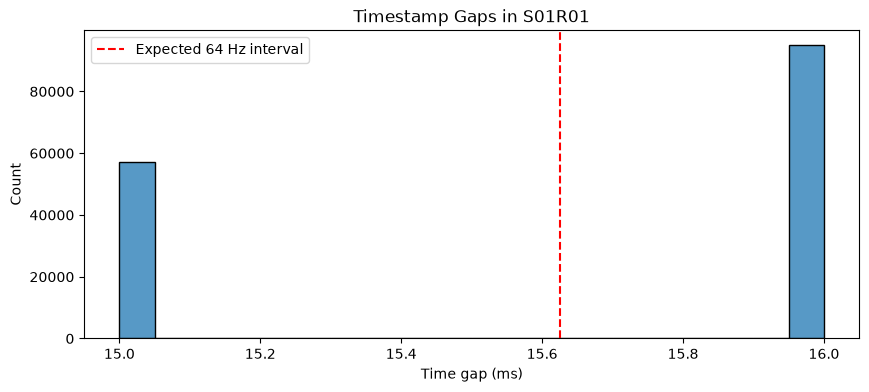

In [5]:
time_differences = example_recording_df["time_ms"].diff().dropna()

print("Time-gap summary in milliseconds:")
display(time_differences.describe())

print("Observed time intervals:")
print(sorted(time_differences.unique())[:20])

expected_interval_ms = 1000 / 64
print(f"\nExpected interval at 64 Hz: {expected_interval_ms:.3f} ms")

plt.figure(figsize=(10, 4))
sns.histplot(time_differences, bins=20)
plt.axvline(
    expected_interval_ms,
    color="red",
    linestyle="--",
    label="Expected 64 Hz interval",
)
plt.title(f"Timestamp Gaps in {example_participant}{example_recording}")
plt.xlabel("Time gap (ms)")
plt.legend()
plt.show()

### clean experimental samples

The Daphnet annotation `0` means **outside the experiment**. It is not a
non-freezing observation, so it must not become part of the binary classifier.

For modelling:

- Keep annotation `1` as no freezing.
- Keep annotation `2` as freezing of gait.
- Remove annotation `0`.
- Create `fog_label`, where `0 = no freezing` and `1 = freezing`.

Because this is time-series data, filtering annotation `0` alone is not enough.
It can make two unrelated experimental periods appear adjacent. Therefore, we
also create a `segment_id` whenever:

1. A new recording starts,
2. An experimental period begins after annotation `0`, or
3. A timestamp gap is detected.

Later, sliding windows must stay completely inside one `segment_id`.

In [6]:
EXPECTED_FREQUENCY_HZ = 64
EXPECTED_INTERVAL_MS = 1000 / EXPECTED_FREQUENCY_HZ
TIME_TOLERANCE_MS = 1.0

# Work on a copy: never overwrite the original integrated dataset.
working_df = df.sort_values(
    ["source_file", "time_ms"]
).copy()

# Identify valid experimental samples.
working_df["is_experimental"] = working_df["annotation"].isin([1, 2])

# Compare each row to the immediately previous row.
same_recording = working_df["source_file"].eq(
    working_df["source_file"].shift()
)

time_gap_ms = working_df["time_ms"].diff()

continuous_time = (
    same_recording
    & time_gap_ms.sub(EXPECTED_INTERVAL_MS).abs().le(TIME_TOLERANCE_MS)
)

previous_is_experimental = (
    working_df["is_experimental"]
    .shift()
    .fillna(False)
    .astype(bool)
)

# A segment begins at the start of each uninterrupted experimental region.
new_segment = (
    working_df["is_experimental"]
    & (
        ~previous_is_experimental
        | ~continuous_time
    )
)

working_df["segment_number"] = (
    new_segment.groupby(working_df["source_file"]).cumsum()
)

# Keep only actual experiment data and make the target binary.
clean_df = working_df.loc[
    working_df["is_experimental"]
].copy()

clean_df["fog_label"] = (
    clean_df["annotation"] == 2
).astype("int8")

clean_df["segment_id"] = (
    clean_df["participant_id"]
    + "_"
    + clean_df["recording_id"]
    + "_seg_"
    + clean_df["segment_number"].astype(int).astype(str).str.zfill(2)
)

# Position within the uninterrupted segment; useful later for windowing.
clean_df["sample_in_segment"] = (
    clean_df.groupby("segment_id").cumcount()
)

# Remove helper columns that are not needed in the clean dataset.
clean_df = clean_df.drop(
    columns=["is_experimental", "segment_number"]
)

print(f"Original rows: {len(df):,}")
print(f"Experimental rows retained: {len(clean_df):,}")
print(f"Rows removed (outside experiment): {len(df) - len(clean_df):,}")
print(f"Continuous experimental segments: {clean_df['segment_id'].nunique():,}")

clean_df.head()

Original rows: 1,917,887
Experimental rows retained: 1,140,835
Rows removed (outside experiment): 777,052
Continuous experimental segments: 35


,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,participant_id,recording_id,source_file,fog_label,segment_id,sample_in_segment
47999,750000,-30,990,326,-45,972,181,-38,1000,29,1,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...,0,S01_R01_seg_01,0
48000,750015,-30,1000,356,-18,981,212,-48,1028,29,1,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...,0,S01_R01_seg_01,1
48001,750031,-20,990,336,18,981,222,-38,1038,9,1,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...,0,S01_R01_seg_01,2
48002,750046,-20,1000,316,36,990,222,-19,1038,9,1,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...,0,S01_R01_seg_01,3
48003,750062,0,990,316,36,990,212,-29,1038,29,1,S01,R01,C:\Users\chira\Parkinsons_Fog_Detection\data\r...,0,S01_R01_seg_01,4


In [7]:
assert set(clean_df["annotation"].unique()) == {1, 2}
assert set(clean_df["fog_label"].unique()) == {0, 1}
assert clean_df["fog_label"].eq(clean_df["annotation"].eq(2)).all()
assert clean_df[SENSOR_COLUMNS].isna().sum().sum() == 0

segment_summary = (
    clean_df.groupby(
        ["participant_id", "recording_id", "segment_id"],
        as_index=False,
    )
    .agg(
        samples=("fog_label", "size"),
        start_time_ms=("time_ms", "min"),
        end_time_ms=("time_ms", "max"),
        freezing_samples=("fog_label", "sum"),
    )
)

segment_summary["duration_seconds"] = (
    (segment_summary["end_time_ms"] - segment_summary["start_time_ms"])
    / 1000
)

segment_summary["freezing_percentage"] = (
    segment_summary["freezing_samples"]
    / segment_summary["samples"]
    * 100
).round(2)

display(segment_summary.head(15))

print("\nBinary class distribution:")
display(
    clean_df["fog_label"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No freezing", 1: "Freezing"})
    .to_frame("samples")
)

,participant_id,recording_id,segment_id,samples,start_time_ms,end_time_ms,freezing_samples,duration_seconds,freezing_percentage
0,S01,R01,S01_R01_seg_01,19201,750000,1050000,0,300.0,0.00
1,S01,R01,S01_R01_seg_02,73601,1100000,2250000,5147,1150.0,6.99
2,S01,R02,S01_R02_seg_01,28801,250000,700000,1547,450.0,5.37
3,S02,R01,S02_R01_seg_01,25601,670000,1070000,3537,400.0,13.82
4,S02,R02,S02_R02_seg_01,64961,185000,1200000,8072,1015.0,12.43
5,S03,R01,S03_R01_seg_01,55041,670000,1530000,8153,860.0,14.81
6,S03,R01,S03_R01_seg_02,35841,1620000,2180000,7881,560.0,21.99
7,S03,R02,S03_R02_seg_01,16641,260000,520000,2306,260.0,13.86
8,S03,R03,S03_R03_seg_01,21121,650000,980000,0,330.0,0.00
9,S04,R01,S04_R01_seg_01,99841,740000,2300000,0,1560.0,0.00



Binary class distribution:


,samples
fog_label,
No freezing,1030050
Freezing,110785
